In [1]:
from langgraph.graph import START ,END , StateGraph
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict

d:\Clg Kabir_\Agentic-AI\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv()


True

In [9]:
class SubState(TypedDict):
    input_text:str
    translated_text:str
    

In [10]:
subgraph_llm=ChatGroq(model='llama-3.3-70b-versatile')

In [30]:
def translate_text(state:SubState):
    prompt=f"""
    Translate the following text into Hindi .
    Keep it natural clear and dont add additional content.

    TEXT:{state['input_text']}    
""".strip()

    translate_text=subgraph_llm.invoke(prompt).content
    return {"translated_text":translate_text}

In [31]:
subgraph=StateGraph(SubState)

subgraph.add_node("Translator",translate_text)
subgraph.add_edge(START,"Translator")
subgraph.add_edge("Translator",END)

translator=subgraph.compile()


In [32]:
class ParentState(TypedDict):
    question :str
    answer_eng :str
    answer_hindi:str
    

In [33]:
parent_llm=ChatGroq(model='llama-3.3-70b-versatile')


In [34]:
def generate_answer(state:ParentState):
    answer=parent_llm.invoke(f"""You are a helpul assistant . Answer clearly.
    Question :{state['question']}""").content
    return {'answer_eng':answer}

In [35]:
def translate_answer(state:ParentState):
    # Calling Subgraph
    result=translator.invoke({'input_text': state['answer_eng']})
    return {'answer_hindi':result['translated_text']}


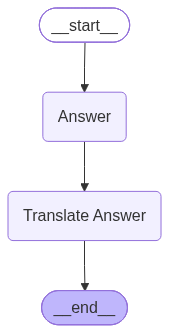

In [36]:
parentgraph=StateGraph(ParentState)

parentgraph.add_node("Answer",generate_answer)
parentgraph.add_node("Translate Answer",translate_answer)

parentgraph.add_edge(START,'Answer')
parentgraph.add_edge("Answer","Translate Answer")
parentgraph.add_edge("Translate Answer",END)

graph=parentgraph.compile()
graph

In [37]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum Physics: A Brief Overview**\n\nQuantum physics, also known as quantum mechanics, is a branch of physics that studies the behavior of matter and energy at an atomic and subatomic level. At these scales, the classical laws of physics do not apply, and strange, seemingly random phenomena govern the behavior of particles.\n\n**Key Principles:**\n\n1. **Wave-Particle Duality**: Quantum objects, such as electrons, can exhibit both wave-like and particle-like behavior depending on how they are observed.\n2. **Uncertainty Principle**: It is impossible to know certain properties of a quantum object, such as its position and momentum, simultaneously with infinite precision.\n3. **Superposition**: Quantum objects can exist in multiple states simultaneously, which is known as a superposition of states.\n4. **Entanglement**: Quantum objects can become "entangled" in a way that the state of one object is dependent on the state of the 